In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
pwd

'/kfs2/projects/pvopt/aps_dfd_2024/PVade/postprocessing'

In [96]:
# copying from https://github.com/brookeslawski/scripts/blob/main/pvade-pproc-aps2024.ipynb
parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
casepath = 'y20m_turbinflow_duramat_validation/'

# create dictionary of case names
tracker_angles0 = [40.0]

# rawdata = {}

u = float_list_to_str_list(u_refs0)[0]
angle = float_list_to_str_list(tracker_angles0)[0]

# rawdata['u_'+u] = {}

output_dir=parentdir+'output/'+casepath
tmp = pd.read_csv(output_dir+'solution/lift_and_drag.csv')
tmp.rename(columns={'#Time': 'Time'}, inplace=True)
tmp = tmp.set_index('Time')
# tmp = tmp.loc[:, ~tmp.columns.str.contains('fz')]
rawdata = tmp

dt_sim = rawdata.index[1] - rawdata.index[0]

tmp2 = pd.read_csv(output_dir+'solution/accel_pos.csv')
tmp2 = tmp2.rename(columns={"#x-pos": "x-pos"})
# tmp2['Time'] = tmp2.index * dt
rawdata['accel-x-pos'] = tmp2['x-pos'].values
rawdata['accel-y-pos'] = tmp2['y-pos'].values
rawdata['accel-z-pos'] = tmp2['z-pos'].values
rawdata['accel-magnitude'] = rawdata['accel-x-pos']**2 + rawdata['accel-y-pos']**2 + rawdata['accel-z-pos']**2
rawdata

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x-pos,accel-y-pos,accel-z-pos,accel-magnitude
Time,,,,,,,,,,
0.006,80095.786570,25.356473,94328.264350,43.713611,0.013839,51.481223,0.000000,0.000000,0.000000,0.000000e+00
0.012,15358.255090,16.459162,16302.197970,8.382024,0.008983,8.897196,0.003672,-0.000060,0.004102,3.031568e-05
0.018,5395.130808,10.003737,4495.901407,2.944483,0.005460,2.453713,0.010679,-0.000048,0.011900,2.556458e-04
0.024,10068.180040,2.107822,11408.066990,5.494877,0.001150,6.226143,0.006625,0.000050,0.007275,9.683186e-05
0.030,8709.975539,-2.303399,9799.812632,4.753614,-0.001257,5.348411,-0.010980,-0.000066,-0.012541,2.778219e-04
...,...,...,...,...,...,...,...,...,...,...
29.976,2749.613209,-6.071575,3032.472308,1.500647,-0.003314,1.655022,-0.000248,-0.000011,-0.000319,1.632866e-07
29.982,2797.885123,-6.294778,3087.542732,1.526992,-0.003435,1.685078,-0.000251,-0.000011,-0.000322,1.667396e-07
29.988,2825.244245,-6.449536,3116.306275,1.541924,-0.003520,1.700776,-0.000285,-0.000011,-0.000359,2.103726e-07


In [97]:
# read in experimental data
def read_csv_data(raw_data):
    # read csv
    # raw_data = pd.read_csv(sonic_data_fn, header=None)
    sonic_data = raw_data
    
    # downsample from 50 Hz to 4 Hz (sonic resolution)
    # sonic_data = sonic_data.resample('250ms').median() # 4 Hz = 250 milliseconds

    # construct time index
    # print(sonic_data.index[1])
    tmp = (sonic_data.index[1]-sonic_data.index[0])
    dt_sonic1 = round(tmp.total_seconds(), 3)
    # print(dt_sonic1)
    tf_sonic1 = len(sonic_data) * dt_sonic1 # final time [s]
    # print(tf_sonic1)
    t_sonic1 = np.arange(0.0, tf_sonic1, dt_sonic1)

    # sonic_data = sonic_data.rename(columns={'u (m/s)':'u_p0', 'v (m/s)':'v_p0', 'w (m/s)':'w_p0'})
    sonic_data['u (m/s)'] = -1.0*sonic_data['u (m/s)'] # to make it positive from the west
    sonic_data['Time'] = t_sonic1
    sonic_data = sonic_data.set_index('Time')

    return tf_sonic1, sonic_data
    
sonic_data_fn = 'DuraMAT_tiltneg40deg_turbulent_inflow_10min_timeseries.csv'
raw_sonic_data = pd.read_csv(sonic_data_fn, index_col='Time')
raw_sonic_data.index = pd.to_datetime(raw_sonic_data.index)

tf_sonic1, sonic_data = read_csv_data(raw_sonic_data)
dt = sonic_data.index[1]-sonic_data.index[0]

# cut sonic data to time period simulated
sonic_data = sonic_data[sonic_data.index <= rawdata.index[-1]]

sonic_data

,3D wind speed (m/s),Wind direction (deg),u (m/s),v (m/s),w (m/s),temp (degC),Drive tracker angle (deg),Drive torque north (kNm),Panel defl mid (mm),Drag force (kN),Lift force (kN),Drag force tracker angle (kN),Lift force tracker angle (kN)
Time,,,,,,,,,,,,,
0.00,4.659901,257.54547,4.544404,-1.003686,0.235973,10.154514,-40.449590,1.577996,-1.452403,2.461932,-2.934016,2.484879,-2.914608
0.02,4.659763,257.53207,4.544037,-1.004721,0.235909,10.152960,-40.447216,1.577571,-1.404736,2.461270,-2.933227,2.484090,-2.913927
0.04,4.659775,257.53980,4.544183,-1.004110,0.235947,10.155216,-40.446830,1.549748,-1.360116,2.417861,-2.881494,2.440259,-2.862551
0.06,5.624049,237.23671,4.620632,-2.973606,1.198899,10.347651,-40.450085,1.524818,-1.312926,2.378967,-2.835142,2.401165,-2.816367
0.08,5.625453,237.22455,4.621097,-2.975292,1.199510,10.348604,-40.451576,1.487232,-1.314180,2.320325,-2.765256,2.342047,-2.746882
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.92,5.623761,276.05084,5.290473,0.560798,1.822935,10.397666,-40.451023,1.443200,-1.281602,2.251629,-2.683387,2.272682,-2.665580
29.94,5.624513,276.04474,5.291386,0.560325,1.822751,10.397315,-40.449480,1.457903,-1.282190,2.274568,-2.710725,2.295763,-2.692797
29.96,5.624513,276.03380,5.291569,0.559324,1.822528,10.398694,-40.446940,1.463383,-1.250450,2.283117,-2.720913,2.304273,-2.703021


In [98]:
# calculate lift and drag force coefficients
panel_span = 10.0
panel_chord = 4.1
sfc_area = panel_span * panel_chord
sonic_data['Drag Coefficient'] = (sonic_data['Drag force tracker angle (kN)']*1000)/(0.5*1*sonic_data['3D wind speed (m/s)']**2*sfc_area)
sonic_data['Lift Coefficient'] = (sonic_data['Lift force tracker angle (kN)']*1000)/(0.5*1*sonic_data['3D wind speed (m/s)']**2*sfc_area)

In [99]:
# interpolate to 50 Hz to match duramat loads signals
new_time_index = sonic_data[sonic_data.index>0.0].index
interp_sim_data = pd.DataFrame(index=new_time_index)
for col in rawdata.columns:
    interpolator = interp1d(rawdata.index, rawdata[col].values, kind='linear')  # Use 'linear' or 'cubic' as needed
    interp_sim_data[col] = interpolator(new_time_index)

interp_sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x-pos,accel-y-pos,accel-z-pos,accel-magnitude
Time,,,,,,,,,,
0.02,6952.813885,7.371765,6799.956601,3.794614,0.004023,3.711190,0.009328,-0.000015,0.010358,2.027078e-04
0.04,-3612.071976,1.003233,-4649.960525,-1.971349,0.000548,-2.537793,-0.005903,-0.000096,-0.006841,2.217167e-04
0.06,6551.188208,-2.773338,7677.709417,3.575420,-0.001514,4.190238,-0.009872,-0.000130,-0.010940,2.171593e-04
0.08,9925.812304,-2.165652,11794.850210,5.417178,-0.001182,6.437236,-0.001258,-0.000053,-0.001547,7.282681e-05
0.10,3500.954128,-2.181478,4187.521554,1.910704,-0.001191,2.285410,0.006502,-0.000003,0.007139,1.035890e-04
...,...,...,...,...,...,...,...,...,...,...
29.92,2532.106151,-5.569994,2806.016115,1.381939,-0.003040,1.531430,-0.000252,-0.000011,-0.000323,1.699048e-07
29.94,2628.654073,-5.600960,2909.274066,1.434632,-0.003057,1.587785,-0.000317,-0.000012,-0.000397,2.586497e-07
29.96,2784.923558,-5.942468,3077.725183,1.519918,-0.003243,1.679720,-0.000293,-0.000012,-0.000371,2.244782e-07


In [104]:
# merge dataframes
alldata = {}

alldata['exp'] = sonic_data.copy()
alldata['sim'] = interp_sim_data.copy()

# adjustments
for comp in ['fx','fy','fz']:
    alldata['sim'][comp+'_0'] = alldata['sim'][comp+'_0']/1000
    
alldata['sim'] = alldata['sim'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})

alldata['sim']

,Drag force (kN),Lateral force (kN),Lift force (kN),fx_nd_0,fy_nd_0,fz_nd_0,accel-x-pos,accel-y-pos,accel-z-pos,accel-magnitude
Time,,,,,,,,,,
0.02,6.952814,0.007372,6.799957,3.794614,0.004023,3.711190,0.009328,-0.000015,0.010358,2.027078e-04
0.04,-3.612072,0.001003,-4.649961,-1.971349,0.000548,-2.537793,-0.005903,-0.000096,-0.006841,2.217167e-04
0.06,6.551188,-0.002773,7.677709,3.575420,-0.001514,4.190238,-0.009872,-0.000130,-0.010940,2.171593e-04
0.08,9.925812,-0.002166,11.794850,5.417178,-0.001182,6.437236,-0.001258,-0.000053,-0.001547,7.282681e-05
0.10,3.500954,-0.002181,4.187522,1.910704,-0.001191,2.285410,0.006502,-0.000003,0.007139,1.035890e-04
...,...,...,...,...,...,...,...,...,...,...
29.92,2.532106,-0.005570,2.806016,1.381939,-0.003040,1.531430,-0.000252,-0.000011,-0.000323,1.699048e-07
29.94,2.628654,-0.005601,2.909274,1.434632,-0.003057,1.587785,-0.000317,-0.000012,-0.000397,2.586497e-07
29.96,2.784924,-0.005942,3.077725,1.519918,-0.003243,1.679720,-0.000293,-0.000012,-0.000371,2.244782e-07


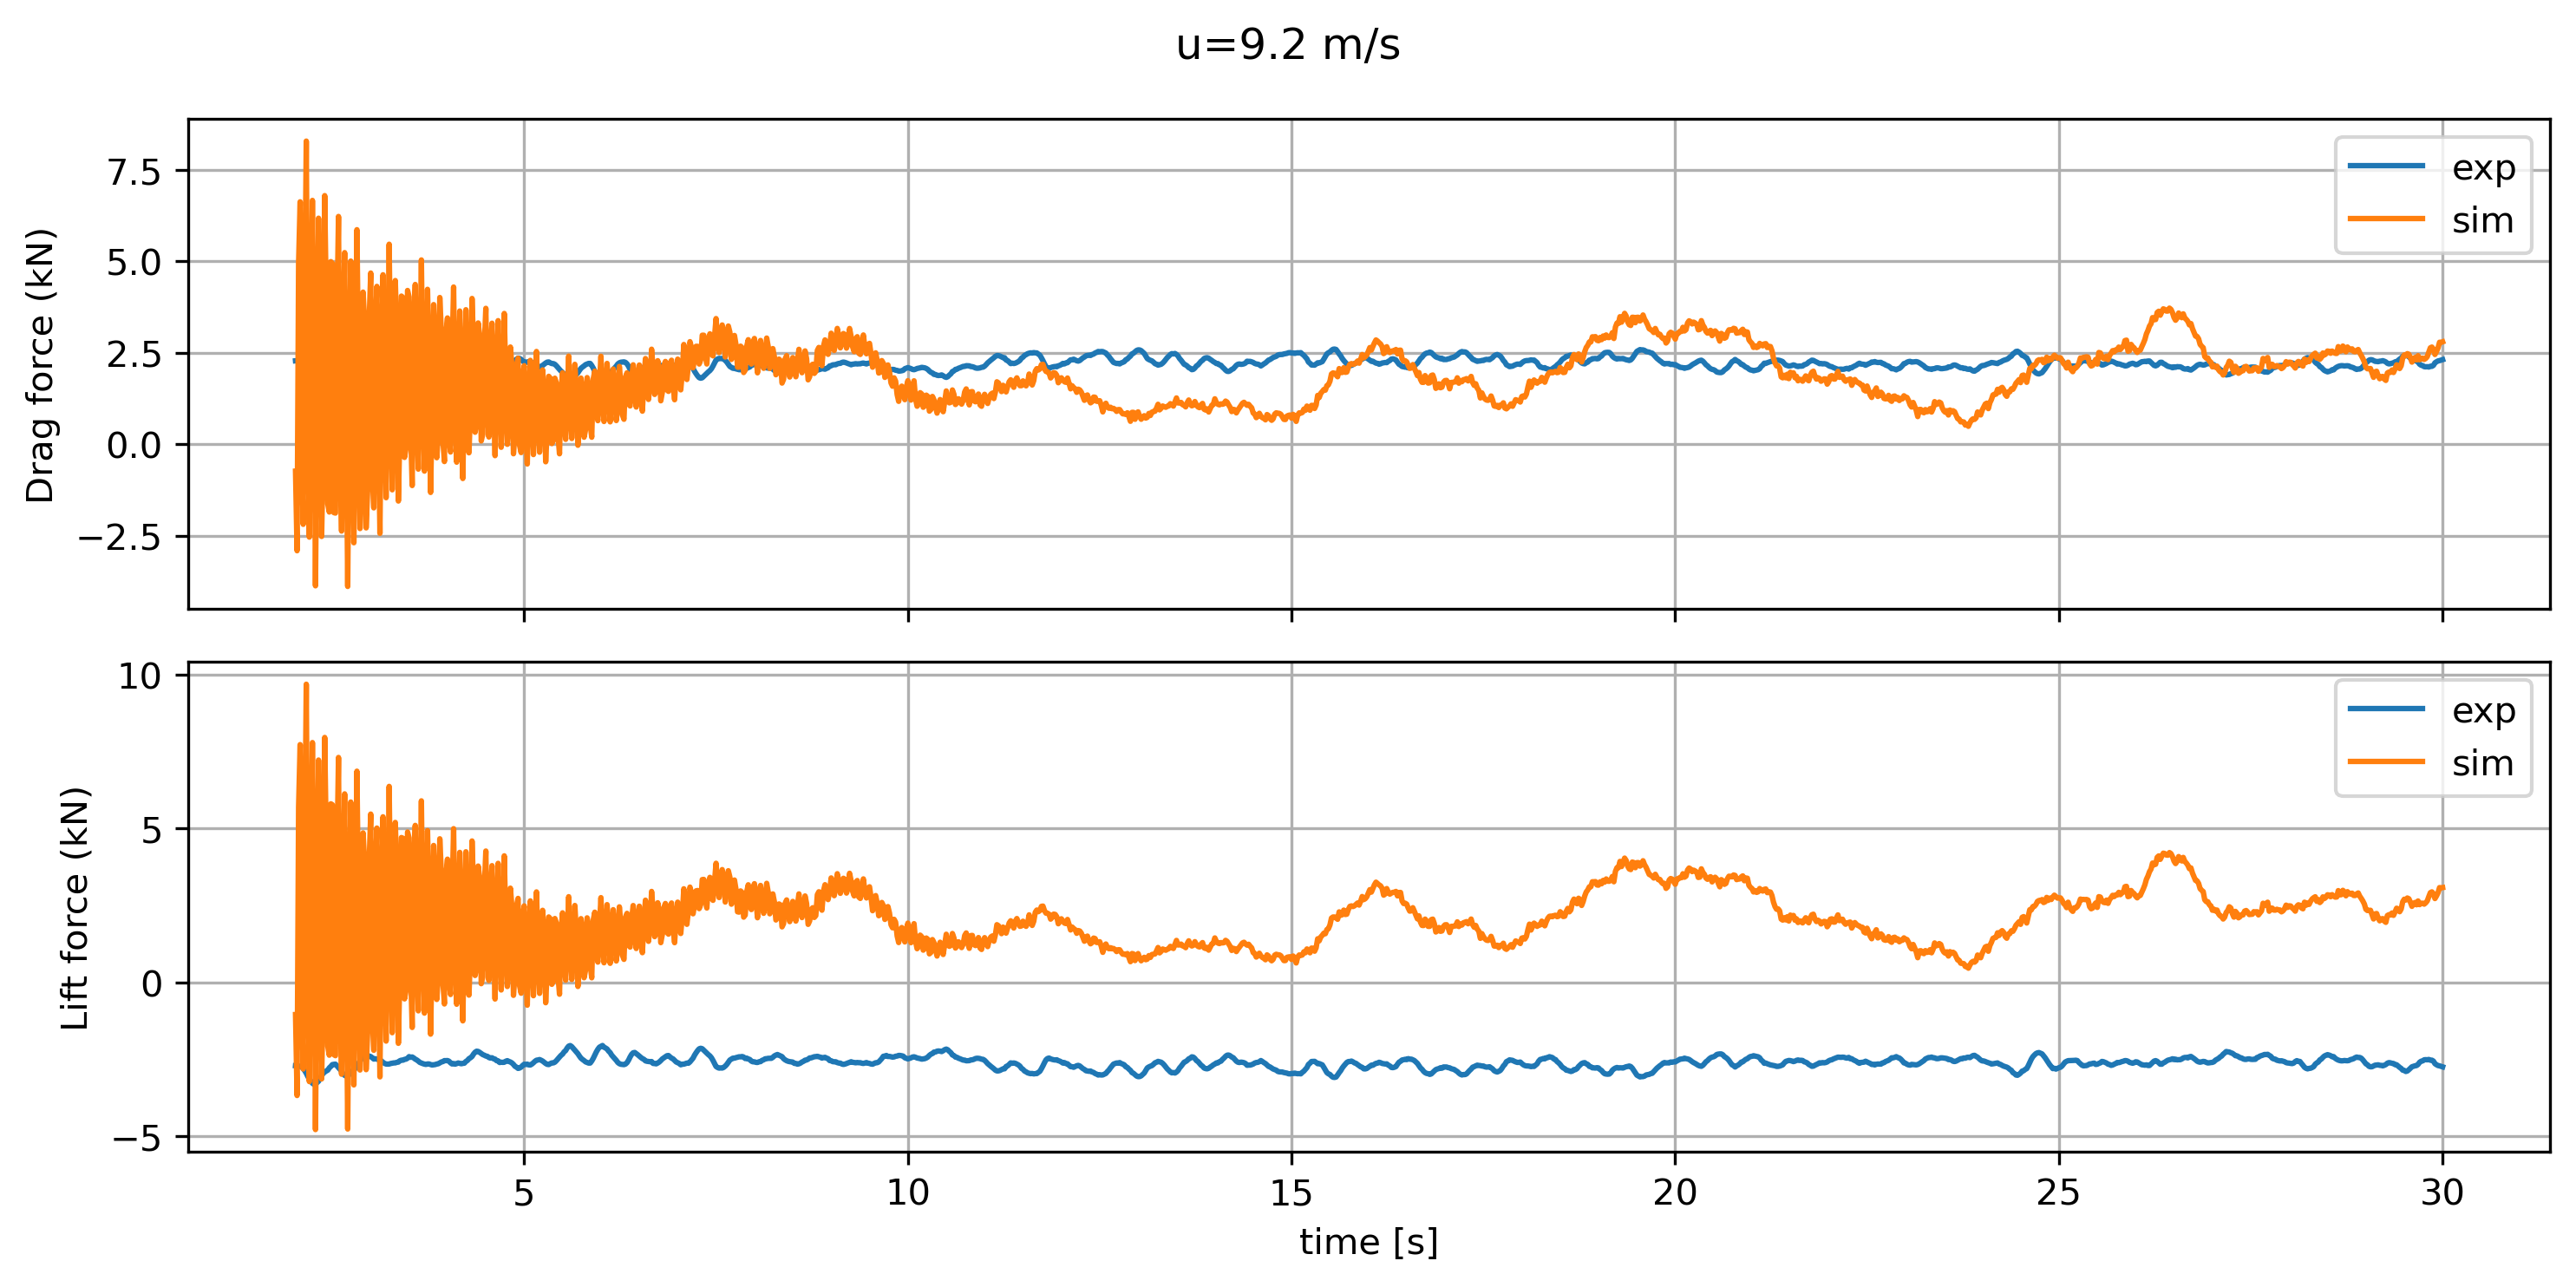

In [106]:
# first glance at all timeseries
plt.style.use('default')

# sel_quantities = ['fx_0', 'fz_0']
# # sel_quantities = ['fx_nd_0', 'fz_nd_0']

# meas_quantities = ['Drag force tracker angle (kN)', 'Lift force tracker angle (kN)']
# # meas_quantities = ['Drag Coefficient', 'Lift Coefficient']

vars = ['Drag force (kN)', 'Lift force (kN)']

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
fig, axs = plt.subplots(2,len(u_refs0),figsize=[10,5],sharex=True, dpi=300) #, sharey=True)
plt.suptitle('u='+u+' m/s')
# for j,u in enumerate(float_list_to_str_list(u_refs0)):
# plotdata = rawdata[rawdata.index > 2.0]
# plotinterpdata = interp_sim_data[interp_sim_data.index > 2.0]

for n,var in enumerate(vars):
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > 2.0]
        axs[n].plot(pltdata, label=key)
        # axs[n].plot(sonic_data[meas_quantities[n]], label='experimental')
        # # axs[0].plot(sonic_data['Drag force (kN)'], label='experimental')
        # # axs[n].plot(plotdata[var]/1000, linewidth=0.75, label='simulated')
        # axs[n].plot(plotinterpdata[var]/1000, linewidth=0.75, label='sim,interpolated')
        axs[n].set_ylabel(var)
        # axs[n].set_ylabel(var)
        axs[n].legend()
        # axs[0].set_xlim([15, 20])
        # axs[0].set_ylim([0.0, 4.0])

for ax in axs:
    ax.grid()
    # ax.legend()

# for ax in axs:
axs[-1].set_xlabel('time [s]')

plt.tight_layout()

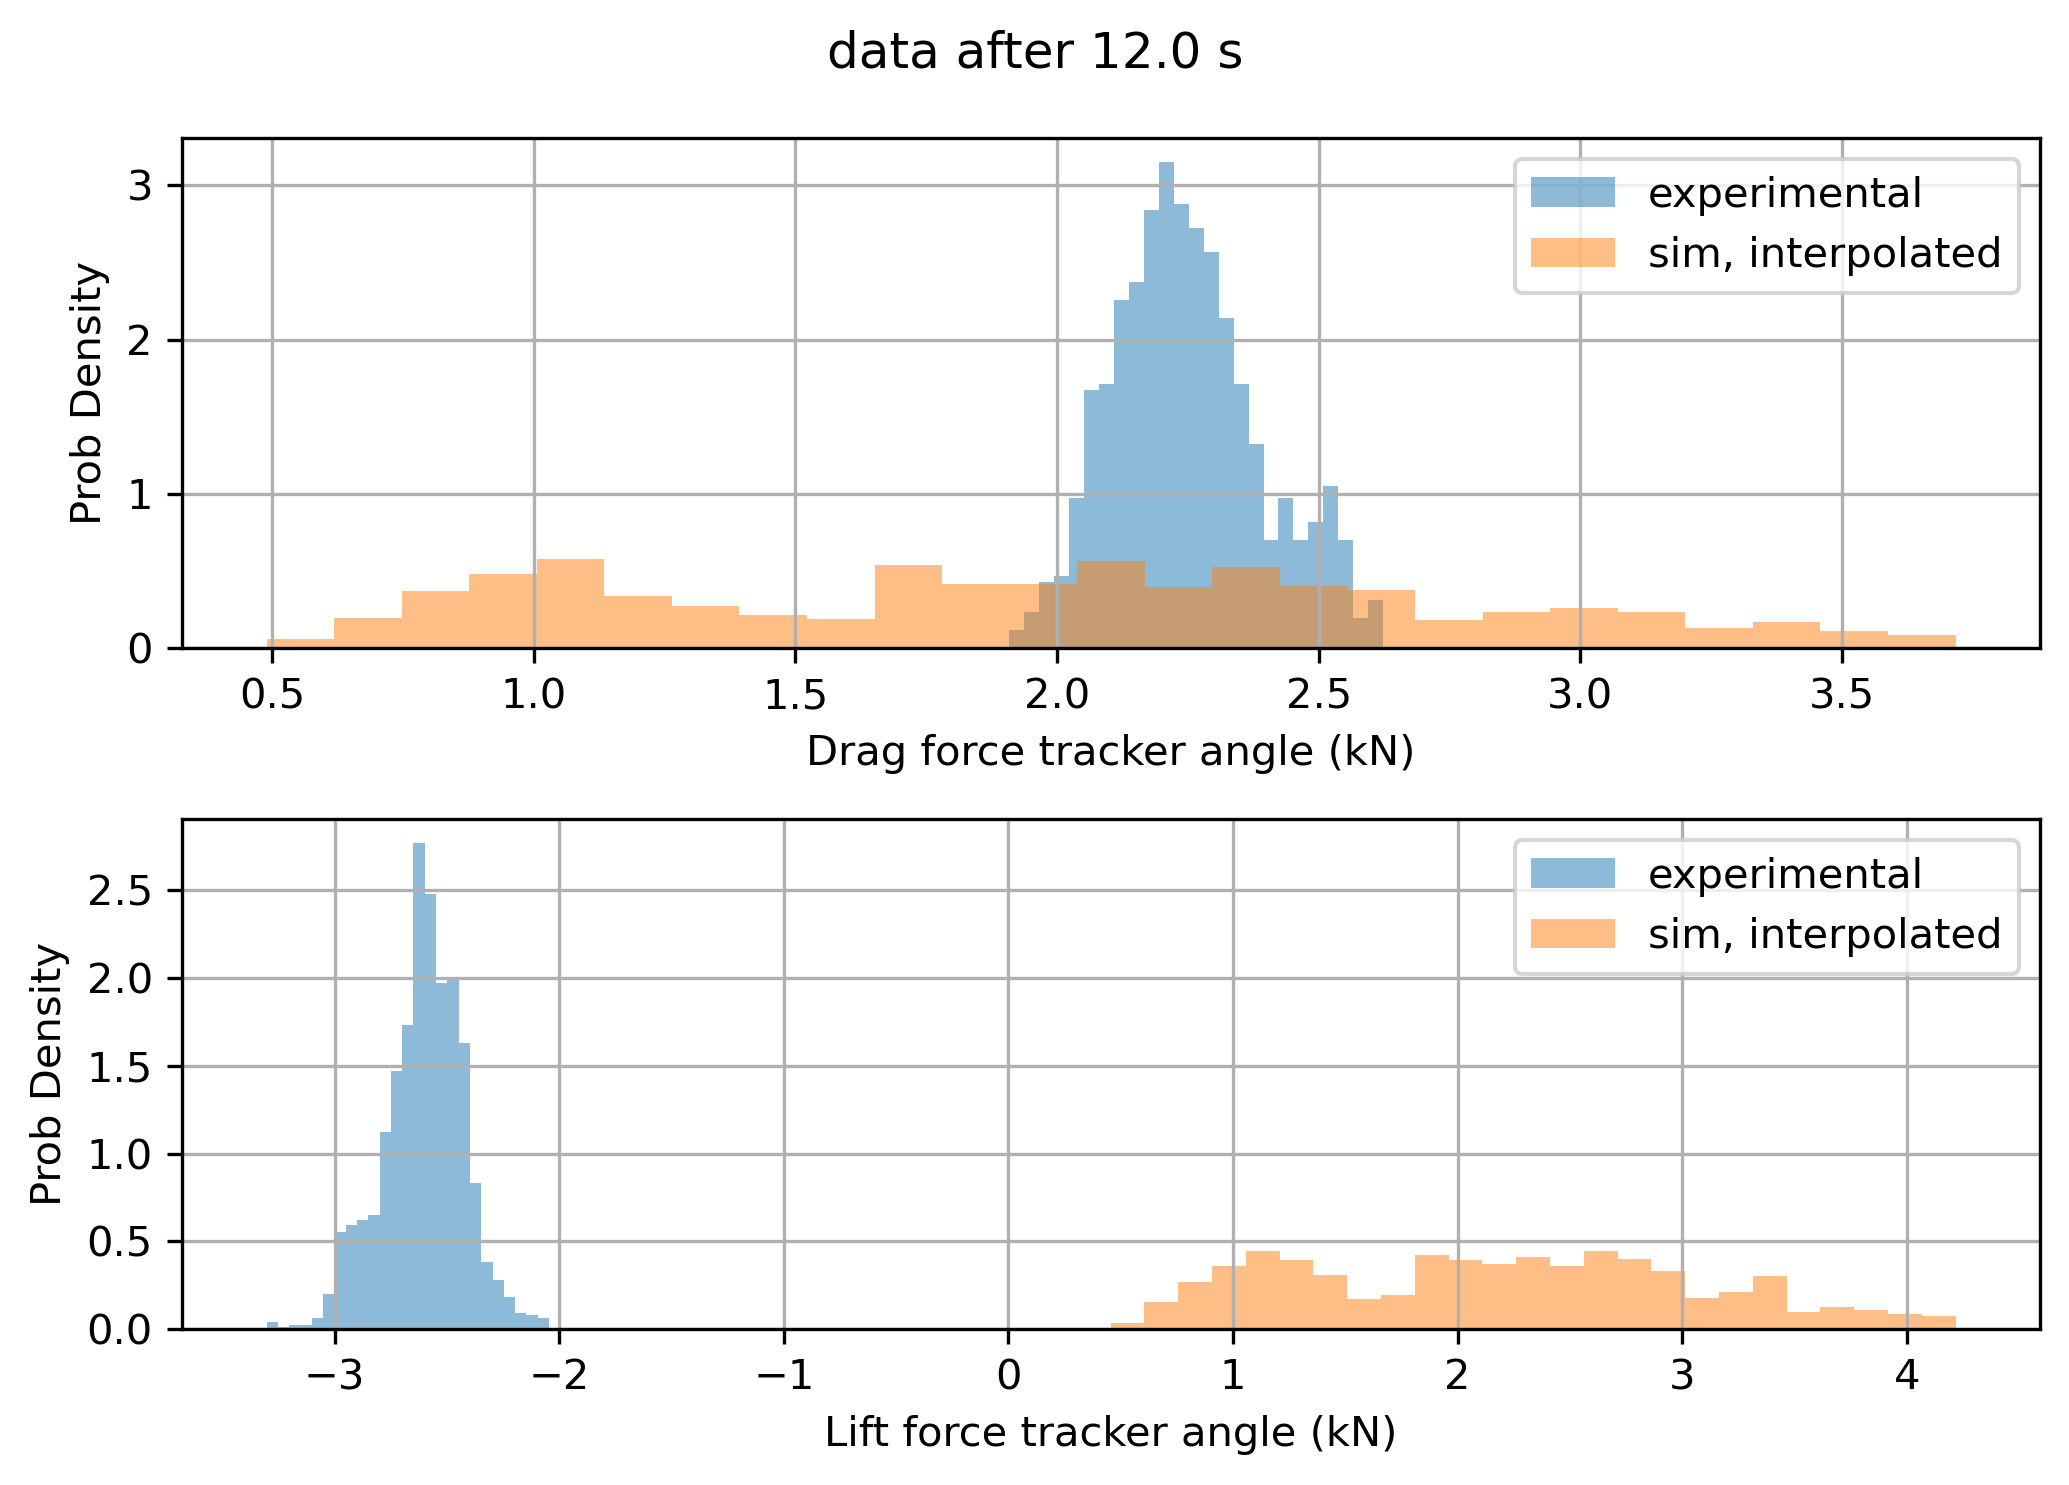

In [88]:
# histograms
time_threshold = 12.0 # s
plotdata = interp_sim_data[interp_sim_data.index > time_threshold]
plt_sonic_data = sonic_data[sonic_data.index > time_threshold]

nbins = 25

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
fig, axs = plt.subplots(2,len(u_refs0),figsize=[7,5], dpi=300) #, sharey=True)
plt.suptitle(f'data after {time_threshold} s')
# for j,u in enumerate(float_list_to_str_list(u_refs0)):

axs[0].hist(plt_sonic_data['Drag force tracker angle (kN)'], bins=nbins, density=True, alpha=0.5, label='experimental')
axs[0].hist(plotdata['fx_0']/1000, bins=nbins, density=True, alpha=0.5, label='sim, interpolated')
axs[0].set_xlabel('Drag force tracker angle (kN)')

axs[1].hist(sonic_data['Lift force tracker angle (kN)'], bins=nbins, density=True, alpha=0.5, label='experimental')
axs[1].hist(plotdata['fz_0']/1000, bins=nbins, alpha=0.5, density=True, label='sim, interpolated')
axs[1].set_xlabel('Lift force tracker angle (kN)')

# axs[0].set_title('u='+u+' m/s')

for ax in axs:
    ax.grid()
    ax.legend()
    ax.set_ylabel('Prob Density')

# # for ax in axs:
# axs[-1].set_xlabel('time [s]')

plt.tight_layout()